# Intro to LangGraph — the framework in a few cells

A tiny, self-contained tour of **LangGraph**, the library the agents track uses later (Lecture 4 — multi-agent).

> **Framing:** what we build here is a *workflow*, **not yet an agent** — there is no LLM reasoning in the loop, just deterministic Python nodes. Think of LangGraph as a **flowchart engine**: you declare a shared **State**, wire up **Nodes** (units of work) with **Edges** (flow), and it runs the graph for you. In the agents track, the nodes become LLM-powered agents.


## Setup

Install once (already installed in the course venv). Uncomment if running in Colab:


In [1]:
# !pip install -U langgraph

## 1. State — the data every node reads & writes

State is just a typed dictionary that flows through the graph.


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class PizzaState(TypedDict):
    order: str
    confirmed: bool

ModuleNotFoundError: No module named 'langgraph'

## 2. Nodes — plain functions `state -> state`

Each node does one small task. We keep them **deterministic** (no blocking `input()`), so the notebook runs top-to-bottom.


In [10]:
MENU = {"margherita", "pepperoni", "veggie"}

def take_order(state: PizzaState) -> PizzaState:
    print(f"Bot: order received -> {state['order']}")
    return state

def confirm_order(state: PizzaState) -> PizzaState:
    state["confirmed"] = state["order"].lower() in MENU
    mark = "on the menu" if state["confirmed"] else "NOT on the menu"
    print(f"Bot: '{state['order']}' is {mark}")
    return state

def finalize_order(state: PizzaState) -> PizzaState:
    if state["confirmed"]:
        print(f"Bot: great! your {state['order']} pizza is on the way!")
    else:
        print("Bot: sorry, we can't make that one.")
    return state

## 3. Edges — wire the nodes into a graph, then compile


In [11]:
workflow = StateGraph(PizzaState)
workflow.add_node("take_order", take_order)
workflow.add_node("confirm_order", confirm_order)
workflow.add_node("finalize_order", finalize_order)

workflow.set_entry_point("take_order")
workflow.add_edge("take_order", "confirm_order")
workflow.add_edge("confirm_order", "finalize_order")
workflow.add_edge("finalize_order", END)

graph = workflow.compile()

## 4. Visualize the flow

We ask the compiled graph to describe itself as **Mermaid** (a text-based flowchart format). We then wrap it in a Markdown block so VS Code / Jupyter renders it as an actual diagram. In Colab you can also call `draw_mermaid_png()` for a PNG.



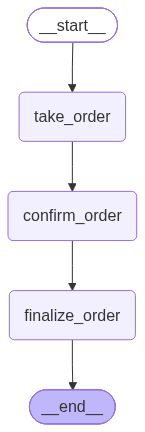

In [16]:
from IPython.display import Markdown, Image, display

def show_graph(compiled_graph):
    """Render a LangGraph as an inline diagram.
    Tries a PNG (via mermaid.ink) first; falls back to a Mermaid markdown block
    which VS Code / JupyterLab render natively.
    """
    try:
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception:
        mermaid_src = compiled_graph.get_graph().draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid_src}\n```"))

show_graph(graph)


## 5. Run it

We pass the starting state in via `invoke` — no interactive prompts needed.


In [18]:
print("--- valid order ---")
graph.invoke({"order": "pepperoni", "confirmed": False})

print("\n--- invalid order ---")
graph.invoke({"order": "pineapple surprise", "confirmed": False})

--- valid order ---
Bot: order received -> pepperoni
Bot: 'pepperoni' is on the menu
Bot: great! your pepperoni pizza is on the way!

--- invalid order ---
Bot: order received -> pineapple surprise
Bot: 'pineapple surprise' is NOT on the menu
Bot: sorry, we can't make that one.


{'order': 'pineapple surprise', 'confirmed': False}

## 6. Conditional edges — branching on state

Real workflows branch. A **conditional edge** routes to different nodes based on the current state. Here: if the order isn't on the menu, we auto-suggest a fix instead of failing.


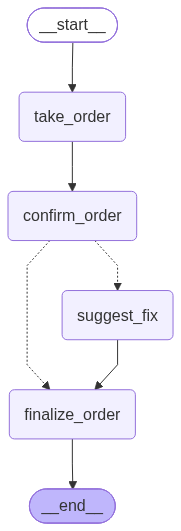

In [17]:
def suggest_fix(state: PizzaState) -> PizzaState:
    print("Bot: let me swap that to our popular 'margherita'.")
    state["order"] = "margherita"
    state["confirmed"] = True
    return state

def decide_next(state: PizzaState) -> str:
    return "finalize_order" if state["confirmed"] else "suggest_fix"

wf2 = StateGraph(PizzaState)
wf2.add_node("take_order", take_order)
wf2.add_node("confirm_order", confirm_order)
wf2.add_node("suggest_fix", suggest_fix)
wf2.add_node("finalize_order", finalize_order)

wf2.set_entry_point("take_order")
wf2.add_edge("take_order", "confirm_order")
wf2.add_conditional_edges("confirm_order", decide_next,
                          {"finalize_order": "finalize_order", "suggest_fix": "suggest_fix"})
wf2.add_edge("suggest_fix", "finalize_order")
wf2.add_edge("finalize_order", END)

graph2 = wf2.compile()
show_graph(graph2)


In [15]:
print("--- on-menu order goes straight through ---")
graph2.invoke({"order": "veggie", "confirmed": False})

print("\n--- off-menu order gets auto-fixed by the branch ---")
graph2.invoke({"order": "pineapple surprise", "confirmed": False})

--- on-menu order goes straight through ---
Bot: order received -> veggie
Bot: 'veggie' is on the menu
Bot: great! your veggie pizza is on the way!

--- off-menu order gets auto-fixed by the branch ---
Bot: order received -> pineapple surprise
Bot: 'pineapple surprise' is NOT on the menu
Bot: let me swap that to our popular 'margherita'.
Bot: great! your margherita pizza is on the way!


{'order': 'margherita', 'confirmed': True}

## 7. Try it yourself — talk to the bot

Now **you** drive the graph. Run the cell below, type an order at the prompt, and watch the workflow route your input:

- On-menu orders (`margherita`, `pepperoni`, `veggie`) go straight through.
- Anything else triggers the `suggest_fix` branch and gets swapped to margherita.

Try a few. Type `quit` to stop.


In [20]:
# Interactive loop: type an order, watch the graph route it.
# Type 'quit' (or leave blank) to stop.
while True:
    order = input("What pizza would you like? (or 'quit'): ").strip()
    if not order or order.lower() in {"quit", "exit", "q"}:
        print("Bot: goodbye!")
        break

    print()  # spacer
    final_state = graph2.invoke({"order": order, "confirmed": False})
    print(f"[final state: {final_state}]\n")



Bot: order received -> veggie
Bot: 'veggie' is on the menu
Bot: great! your veggie pizza is on the way!
[final state: {'order': 'veggie', 'confirmed': True}]

Bot: goodbye!
